This is a cleaner version of the experimental pipeline. The reason behind the creation of this new file is due to the lack of comprehensivness of the experimental pipeline. this is due to the sheer amount of code cells as well as text which has made the comprehension level of the pipeline reduce, as you do not know what is truly needed and what was used as to debug.
this file is meant to help with the problems previosuly stated as well as to update the previous versions of the pipeline, as those had only counted up to phase 1

## GitHub & Environment Setup

## Clone & checkout

In [ ]:
REPO_URL = "https://github.com/Log-Yair/Endymion.git"
REPO_DIR = "/content/Endymion"
BRANCH = "phase2-ml-illum"

import os, sys

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}

%cd {REPO_DIR}
!git checkout {BRANCH}
!git pull


/content/Endymion
Already on 'phase2-ml-illum'
Your branch is up to date with 'origin/phase2-ml-illum'.
Already up to date.


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

PERSIST = "/content/drive/MyDrive/endymion_cache/lola"
RUNTIME = "/content/endymion_runtime_cache/lola"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Verify repo state

In [ ]:
!pwd
!git branch --show-current
!git log -1 --oneline
!ls


/content/Endymion
phase2-ml-illum
7211f69 (HEAD -> phase2-ml-illum, origin/phase2-ml-illum) Rename function for building crater products to improve clarity and update imports accordingly
data  docs  notebooks  README.md  requirements.txt  src


### Make imports work

In [ ]:
import sys
if REPO_DIR not in sys.path:
    sys.path.append(REPO_DIR)

print("sys.path OK:", REPO_DIR in sys.path)


sys.path OK: True


In [ ]:
%cd /content/Endymion
!git branch --show-current
!git pull


/content/Endymion
phase2-ml-illum
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 1), reused 6 (delta 1), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 875.11 KiB | 3.11 MiB/s, done.
From https://github.com/Log-Yair/Endymion
   7211f69..a13d0c4  phase2-ml-illum -> origin/phase2-ml-illum
Updating 7211f69..a13d0c4
Fast-forward
 docs/diagrams/matplot_docsheet.png   | Bin 0 -> 370195 bytes
 docs/diagrams/matplot_docsheet_2.png | Bin 0 -> 542903 bytes
 2 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 docs/diagrams/matplot_docsheet.png
 create mode 100644 docs/diagrams/matplot_docsheet_2.png


### verify content

In [ ]:
# References / notes:
# - Ensures Python can import modules from the repo's src/ folder (data_handler.py, etc.)
# - This replaces the placeholder path that can break imports in Colab.

import sys
SRC_DIR = "/content/Endymion/src"
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print("sys.path contains SRC_DIR:", SRC_DIR in sys.path)


sys.path contains SRC_DIR: True


# Config of Pipeline

This is the control panel. Change things ONLY here

## Imports

In [ ]:
import numpy as np
from pathlib import Path

import numpy as np

from src.data.data_handler import *
from src.features.feature_extractor import *
from src.models.hazard_assessor import *
from src.planning.pathfinder import Pathfinder, build_cost_from_hazard
from src.evaluation.evaluator import Evaluator

In [ ]:

#   base_url + tiles(list[LOLATileSpec]) + persistent_dir + runtime_dir.
# - Uses the canonical ROI already defined in data_handler.py.

BASE = "https://pds-geosciences.wustl.edu/lro/lro-l-lola-3-rdr-v1/lrolol_1xxx/data/lola_gdr/polar/float_img"

tiles = [
    LOLATileSpec(
        tile_id="ldem_85s_20m",
        img_filename="ldem_85s_20m_float.img",
        lbl_filename="ldem_85s_20m_float.lbl",
    )
]

TILE_ID = "ldem_85s_20m"
ROI = CANONICAL_ROI
PIXEL_SIZE_M = 20.0

PERSIST = Path("/content/drive/MyDrive/Endymion/persistent")
RUNTIME = Path("/content/Endymion_runtime")

PERSIST.mkdir(parents=True, exist_ok=True)
RUNTIME.mkdir(parents=True, exist_ok=True)

In [ ]:
#print(BASE)
#print(tiles)

## Prepare or Load terrain

In [ ]:
# References / notes:
# - Constructor matches the current DataHandler backend exactly.

dh = DataHandler(
    base_url=BASE,
    tiles=tiles,
    persistent_dir=PERSIST,
    runtime_dir=RUNTIME,
    allow_download=True,
    force_download=False,
)

## Load DEM

In [ ]:
# References / notes:
# - get_patch() is the proper DataHandler entry point for ROI extraction.
# - Returns a RasterPatch with .data and .meta.

patch = dh.get_patch(TILE_ID, ROI, verbose=True)
dem_m = patch.data

print("DEM shape:", dem_m.shape)
print("Patch meta:", patch.meta.extra)

DEM shape: (1024, 1024)
Patch meta: {'nan_ratio': 0.0, 'min_m': -2872.5341796875, 'max_m': 1738.65771484375, 'lbl_unit': 'KILOMETER', 'lbl_scaling_factor': 1.0, 'lbl_offset': 1737.4, 'tile_shape': (15168, 15168)}


## Extract terrain features

In [ ]:
# References / notes:
# - FeatureExtractor exposes extract(), not compute_slope()/compute_roughness().
# - Returned keys include slope_deg and roughness_rms for the Phase-1 hazard model.

fx = FeatureExtractor(pixel_size_m=PIXEL_SIZE_M, slope_units="degrees")
features = fx.extract(dem_m)

print("Feature keys:", list(features.keys()))
print({k: v.shape for k, v in features.items()})

Feature keys: ['slope_deg', 'slope_rise_run', 'roughness_rms']
{'slope_deg': (1024, 1024), 'slope_rise_run': (1024, 1024), 'roughness_rms': (1024, 1024)}


## Save derived products

In [ ]:
# References / notes:
# - save_derived() stores dem_m.npy, slope_deg.npy, roughness_rms.npy and meta.json
#   under persistent_dir/derived/<tile_id>/<roi_key>/.

derived_dir = dh.save_derived(
    tile_id=TILE_ID,
    roi=ROI,
    dem_m=dem_m,
    features=features,
    meta_extra={"note": "terrain cache regenerated from cleaned experimental pipeline"},
)

print("Derived products saved to:", derived_dir)

Derived products saved to: /content/drive/MyDrive/Endymion/persistent/derived/ldem_85s_20m/roi_7072_8096_7072_8096


## Load derived products

In [ ]:
# References / notes:
# - Keeps the pipeline honest: later stages should work from cache, not notebook state.

cached = dh.load_derived(TILE_ID, ROI)
if cached is None:
    raise RuntimeError("Derived cache not found after save_derived().")

dem_m = cached["dem_m"]
slope = cached["slope_deg"]
rough = cached["roughness_rms"]

print("Cached keys:", list(cached.keys()))
print("DEM shape:", dem_m.shape)
print("Slope shape:", slope.shape)
print("Roughness shape:", rough.shape)

Cached keys: ['meta', 'dem_m', 'slope_deg', 'roughness_rms']
DEM shape: (1024, 1024)
Slope shape: (1024, 1024)
Roughness shape: (1024, 1024)


## Hazard assesor

In [ ]:
# References / notes:
# - HazardAssessor.assess() consumes slope_deg + roughness_rms.
# - dem_m is accepted but currently unused in Phase 1.

ha = HazardAssessor(
    slope_deg_max=38.37,
    roughness_rms_max=19.956,
    w_slope=0.7,
    w_roughness=0.3,
    use_impassable_mask=True,
    impassable_slope_deg=40.0,
)

haz_out = ha.assess(
    slope_deg=slope,
    roughness_rms=rough,
    dem_m=dem_m,
)

hazard = haz_out["hazard"]
hazard_meta = haz_out["meta"]

print("Hazard stats:", hazard_meta["stats"])

Hazard stats: {'hazard_min': 0.0052759707905352116, 'hazard_max': 1.0, 'hazard_mean': 0.4554160237312317, 'nan_ratio': 0.0}


## Build Traversal cost

In [ ]:
# References / notes:
# - build_cost_from_hazard() requires a NaN-free hazard raster.
# - Safety-first policy here: fill NaN hazard as 1.0 before cost construction.

def fill_hazard_nans(h: np.ndarray, fill: float = 1.0) -> np.ndarray:
    out = h.astype(np.float32, copy=True)
    out[np.isnan(out)] = float(fill)
    return out

hazard_safe = fill_hazard_nans(hazard, fill=1.0)

alpha = 10.0
hazard_block = 0.95
block_cost = 1e6

cost = build_cost_from_hazard(
    hazard=hazard_safe,
    alpha=alpha,
    hazard_block=hazard_block,
    block_cost=block_cost,
)

print("Cost shape:", cost.shape)
print("Blocked cells:", int(np.sum(cost >= block_cost)))

Cost shape: (1024, 1024)
Blocked cells: 23596


## Corridor pathfinding

In [ ]:
# References / notes:
# - Uses Pathfinder.find_path_corridor(), which already exists in the backend.
# - No need to manually rebuild the corridor sweep in notebook code.

start = (437, 135) # row col based (y,x)
goal = (237, 960)

pf = Pathfinder(
    connectivity=8,
    block_cost=block_cost,
    heuristic_weight=2.0,
)

corridor_radii = [25, 50, 80, 120, 180, 260, 400]

corr = pf.find_path_corridor(
    cost=cost,
    start=start,
    goal=goal,
    corridor_radii=corridor_radii,
    hazard=hazard_safe,
)

best = corr["best"]
best_radius_px = corr["best_radius_px"]
corridor_experiment = corr["experiment"]

if best is not None and best.get("success", False):
    path_rc = np.asarray(best["path_rc"], dtype=np.int32)
    print("Path found.")
    print("Best corridor radius:", best_radius_px)
    print("Path nodes:", path_rc.shape[0])
    print("Total cost:", best["total_cost"])
    print("Meta:", best["meta"])
else:
    path_rc = np.zeros((0, 2), dtype=np.int32)
    print("No valid path found.")

Path found.
Best corridor radius: 25
Path nodes: 826
Total cost: 4006.007080078125
Meta: {'expansions': 42988, 'connectivity': 8, 'heuristic_weight': 2.0}


## visualise

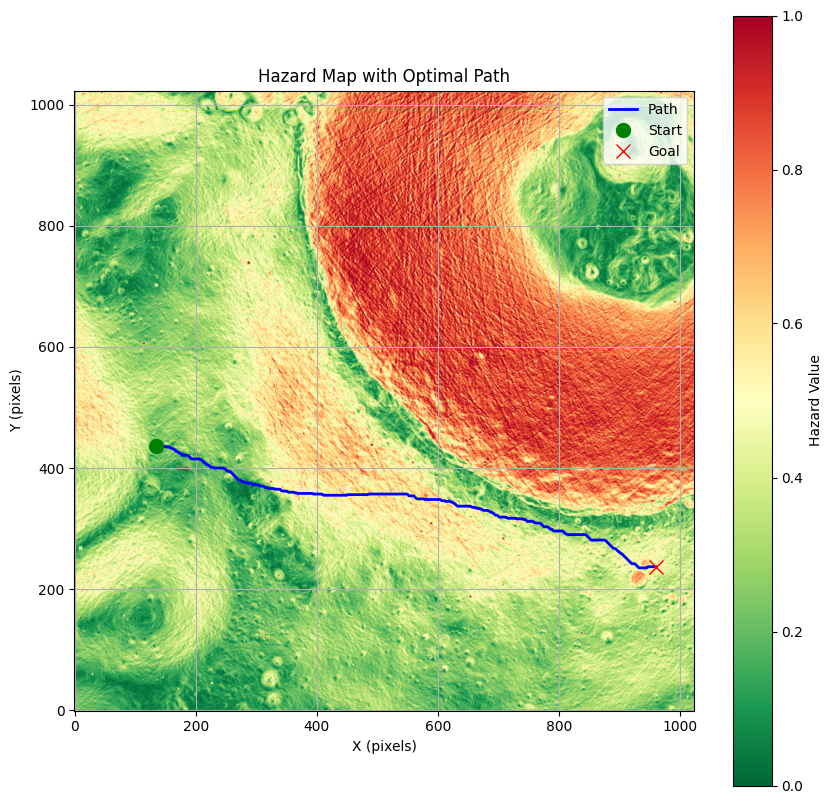

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.imshow(hazard_safe, cmap="RdYlGn_r", origin='lower', vmin=0, vmax=1)
plt.colorbar(label='Hazard Value')
plt.title('Hazard Map with Optimal Path')

# Plot the path
if path_rc.shape[0] > 0:
    plt.plot(path_rc[:, 1], path_rc[:, 0], color='blue', linewidth=2, label='Path')

# Plot start and goal points
plt.plot(start[1], start[0], 'go', markersize=10, label='Start') # green circle
plt.plot(goal[1], goal[0], 'rx', markersize=10, label='Goal')   # red x

plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.legend()
plt.grid(True)
plt.show()

## save nav run

In [ ]:
# References / notes:
# - save_navigation() writes hazard.npy, cost.npy, path_rc.npy, nav_meta.json
#   under derived/<tile>/<roi>/navigation_v1/.
# - Evaluator expects this saved-run structure.

success = bool(best is not None and best.get("success", False))

nav_meta = {
    "start_rc": list(start),
    "goal_rc": list(goal),
    "hazard_assessor": hazard_meta,
    "cost_model": {
        "alpha": float(alpha),
        "hazard_block": float(hazard_block),
        "block_cost": float(block_cost),
    },
    "pathfinder": {
        "connectivity": int(pf.connectivity),
        "heuristic_weight": float(pf.heuristic_weight),
        "corridor_radii": list(map(int, corridor_radii)),
        "corridor_radius_px_used": int(best_radius_px) if best_radius_px is not None else None,
    },
    "result": {
        "success": success,
        "total_cost": float(best["total_cost"]) if success else None,
        "path_len": int(path_rc.shape[0]),
        "expansions": int((best.get("meta") or {}).get("expansions", -1)) if best is not None else -1,
        "failure_reason": None if success else "no_path_found_in_any_corridor",
    },
    "corridor_experiment": corridor_experiment,
}

run_dir = dh.save_navigation(
    tile_id=TILE_ID,
    roi=ROI,
    hazard=hazard_safe,
    cost=cost,
    path_rc=path_rc,
    nav_meta=nav_meta,
    run_name="navigation1_corridor_radius25_pathnode826",
    save_json_path=True,
)

print("Saved navigation run to:", run_dir)

Saved navigation run to: /content/drive/MyDrive/Endymion/persistent/derived/ldem_85s_20m/roi_7072_8096_7072_8096/navigation1_corridor_radius25_pathnode826


## Evaluate run

In [ ]:
# References / notes:
# - Evaluator loads hazard.npy, cost.npy, path_rc.npy and nav_meta.json from run_dir.

ev = Evaluator(run_dir, pixel_size_m=PIXEL_SIZE_M)
metrics = ev.evaluate()

print(metrics)

{'run': {'run_name': 'navigation1_corridor_radius25_pathnode826', 'tile_id': 'ldem_85s_20m', 'roi': [7072, 8096, 7072, 8096]}, 'status': {'success': True, 'failure_reason': None}, 'geometry': {'path_nodes': 826, 'path_length_m': 18223.12841947208, 'straight_line_m': 16977.926846349645, 'detour_ratio': 1.0733423806328957, 'turn_count': 164, 'turns_per_m': 0.00899955244922491}, 'safety': {'path_hazard_mean': 0.34558285430714164, 'path_hazard_max': 0.754521369934082, 'path_hazard_p95': 0.591422975063324, 'haz_per_m': 0.015664238932360467, 'frac_hazard_ge_block': 0.0, 'hazard_mean_ratio': 0.7588289306901744, 'safety_score': 0.9845773452171297}, 'efficiency': {'cost_sum_along_path': 3680.5143818855286, 'cost_per_m': 0.20196940377991104, 'planner_total_cost': 4006.007080078125, 'expansions': 42988}}


## Bechmark

In [ ]:
# References / notes:
# - BenchmarkRunner assumes derived rasters already exist.
# - Keep this as a separate optional section, not part of the main path.

from src.evaluation.benchmark_runner import *

cfg = BenchmarkConfig(
    tile_id=TILE_ID,
    roi=ROI,
    benchmark_id="benchmark_v1", # remember to change for each  different run
    pixel_size_m=PIXEL_SIZE_M,
)

br = BenchmarkRunner(dh, cfg)

# Example:
# results = br.run_benchmark_file("/content/Endymion/benchmarks/benchmark_v1.json")
# print(results)


## crater predictor

In [ ]:
# References / notes:

# - Goal: validate predictor output shape, cache behaviour, and visual plausibility
#   before starting real ML training.

import numpy as np
import matplotlib.pyplot as plt

from src.models.crater_predictor import *
from src.data.crater_raster import build_crater_mask_from_catalogue, CraterRasterConfig
# ---- paths you must set correctly in your own environment ----
ROBBINS_CSV_PATH = "/content/Endymion/data/lunar_crater_database_robbins_2018.csv"

# If needed, resolve the DEM IMG path from your runtime/persistent cache
tile_spec = dh.tiles[TILE_ID]
dem_img_path = dh.runtime_dir / tile_spec.img_filename

print("DEM IMG path:", dem_img_path)
print("Robbins CSV path:", ROBBINS_CSV_PATH)
print("ROI:", ROI)
print("Feature keys:", list(features.keys()))

DEM IMG path: /content/Endymion_runtime/ldem_85s_20m_float.img
Robbins CSV path: /content/Endymion/data/lunar_crater_database_robbins_2018.csv
ROI: typing.Tuple[int, int, int, int]
Feature keys: ['slope_deg', 'slope_rise_run', 'roughness_rms']


In [ ]:
# ---- Test 1: stub predictor ----
cp_stub = CraterPredictor(model_id="stub_v1")

stub_out = cp_stub.predict_proba_map(
    features=features,
    dem_m=dem_m,
    tile_id=TILE_ID,
    roi_pixels=ROI,
    dh=dh,
)

stub_map = stub_out["crater_proba"]
stub_meta = stub_out["meta"]

print("Stub meta:", stub_meta)
print("Stub shape:", stub_map.shape)
print("Stub min/max:", float(np.nanmin(stub_map)), float(np.nanmax(stub_map)))

assert stub_map.shape == dem_m.shape, "Stub crater map shape does not match DEM shape"
assert np.all(stub_map == 0), "Stub predictor should return all zeros"

Stub meta: {'model_id': 'stub_v1', 'note': 'Phase-1 stub: returns zero crater outputs.'}
Stub shape: (1024, 1024)
Stub min/max: 0.0 0.0


In [ ]:
print("ROI:", ROI)
print("type:", type(ROI))
print("dem_img_path exists:", Path(dem_img_path).exists())
print("csv exists:", Path(ROBBINS_CSV_PATH).exists())

ROI: typing.Tuple[int, int, int, int]
type: <class 'typing._GenericAlias'>
dem_img_path exists: True
csv exists: True


ROI  SHOULDNT BE A TYPING CLASS

In [ ]:
from src.data.data_handler import CANONICAL_ROI

ROI_PIXELS = CANONICAL_ROI

assert isinstance(ROI_PIXELS, tuple), f"Expected tuple, got {type(ROI_PIXELS)}"
assert len(ROI_PIXELS) == 4, f"Expected 4 values, got {ROI_PIXELS}"
assert all(isinstance(x, int) for x in ROI_PIXELS), f"ROI values must be ints: {ROI_PIXELS}"

print("ROI_PIXELS:", ROI_PIXELS)

ROI_PIXELS: (7072, 8096, 7072, 8096)


In [ ]:
from pathlib import Path

print("IMG exists:", Path("/content/Endymion_runtime/ldem_85s_20m_float.img").exists())
print("LBL exists:", Path("/content/Endymion_runtime/ldem_85s_20m_float.lbl").exists())

IMG exists: True
LBL exists: True


In [ ]:
# ---- Test 2: catalogue-backed crater raster ----
cp_cat = CraterPredictor(model_id="catalogue_raster_v1")

cat_out = cp_cat.predict_proba_map(
    features=features,
    dem_m=dem_m,
    tile_id=TILE_ID,
    roi_pixels=ROI_PIXELS,
    dh=dh,
    dem_img_path=dem_img_path,
    robbins_csv_path=ROBBINS_CSV_PATH,
    rebuild_if_missing=True,
)
crater_map = cat_out["crater_proba_exp_v1"]
crater_meta = cat_out["meta_exp_v1"]

print("Catalogue meta:", crater_meta)
print("Crater map shape:", crater_map.shape)
print("Unique values:", np.unique(crater_map))
print("Crater coverage ratio:", float(np.mean(crater_map > 0)))

assert crater_map.shape == dem_m.shape, "Catalogue crater map shape does not match DEM shape"
assert crater_map.dtype in (np.float32, np.float64, np.uint8), "Unexpected crater map dtype"

RasterioIOError: '/content/Endymion_runtime/ldem_85s_20m_float.img' not recognized as being in a supported file format.

In [ ]:
# ---- Test 3: cached reload ----
cat_out_cached = cp_cat.predict_proba_map(
    features=features,
    dem_m=dem_m,
    tile_id=TILE_ID,
    roi_pixels=ROI,
    dh=dh,
    rebuild_if_missing=False,
)

crater_map_cached = cat_out_cached["crater_proba"]
cached_meta = cat_out_cached["meta"]

print("Cached meta:", cached_meta)

assert crater_map_cached.shape == crater_map.shape
assert np.array_equal(crater_map_cached, crater_map), "Cached crater map differs from rebuilt map"

In [ ]:
# ---- Visual inspection ----
plt.figure(figsize=(8, 8))
plt.imshow(dem_m, cmap="gray")
plt.imshow(crater_map, cmap="Reds", alpha=0.35)
plt.title("DEM with crater mask overlay")
plt.colorbar()
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(crater_map, cmap="gray")
plt.title("Crater mask only")
plt.colorbar()
plt.show()